In [ ]:
pip install sentence-transformers

In [ ]:
pip install kneed

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv("/content/Dummy_Teachers_Data_version2.csv")

In [ ]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Teacher_ID,Full_Name,Subject,Grade_Level,Years_Exp,Regional_Priority_Skills,School_SES_Rating,Student_Teacher_Ratio,Region,Skills
0,0,0,T1000,Teacher_0,Computer Science,9,11,"AI_Literacy, Digital_Citizenship",0.26,31.0,Semi-Urban,"Python/Java, Algorithms, Web Development, Cybe..."
1,1,1,T1001,Teacher_1,Physics,9,15,Data_Ethics,0.63,23.3,Urban,"Thermodynamics, Calculus-based Modeling, Lab S..."
2,2,2,T1002,Teacher_2,Biology,12,4,Climate_Science,0.84,17.4,Urban,"Genetics, Microscopy, Inquiry-based Learning, ..."
3,3,3,T1003,Teacher_3,Computer Science,7,4,"AI_Literacy, Digital_Citizenship",0.81,17.2,Rural,"Python/Java, Algorithms, Web Development, Cybe..."
4,4,4,T1004,Teacher_4,World History,6,1,Standard_Curriculum,0.85,19.3,Rural,"Historiography, Archival Research, Cultural Co..."


In [ ]:
df.drop(columns=["Unnamed: 0.1","Unnamed: 0"], inplace=True)

In [ ]:
df.head()

,Teacher_ID,Full_Name,Subject,Grade_Level,Years_Exp,Regional_Priority_Skills,School_SES_Rating,Student_Teacher_Ratio,Region,Skills
0,T1000,Teacher_0,Computer Science,9,11,"AI_Literacy, Digital_Citizenship",0.26,31.0,Semi-Urban,"Python/Java, Algorithms, Web Development, Cybe..."
1,T1001,Teacher_1,Physics,9,15,Data_Ethics,0.63,23.3,Urban,"Thermodynamics, Calculus-based Modeling, Lab S..."
2,T1002,Teacher_2,Biology,12,4,Climate_Science,0.84,17.4,Urban,"Genetics, Microscopy, Inquiry-based Learning, ..."
3,T1003,Teacher_3,Computer Science,7,4,"AI_Literacy, Digital_Citizenship",0.81,17.2,Rural,"Python/Java, Algorithms, Web Development, Cybe..."
4,T1004,Teacher_4,World History,6,1,Standard_Curriculum,0.85,19.3,Rural,"Historiography, Archival Research, Cultural Co..."


## Converting into text for embeddings

In [ ]:
def teacher_to_text(row):
    economic_label = (
        "low income school" if row["School_SES_Rating"] < 0.5
        else "moderate income school"
    )

    class_label = (
        "small class size"
        if row["Student_Teacher_Ratio"] < 25
        else "large class size"
    )

    return (
        f"Teaches {row['Subject']} to {row['Grade_Level']} grade. "
        f"Has {row['Years_Exp']} years of experience. "
        f"Expert in {row['Skills']}. "
        f"Works in a {economic_label} with {class_label}. "
        f"Regional Priority skills are :{row['Regional_Priority_Skills']}. "
        f"Region: {row['Region']}."
    )

df["Teacher_profile"] = df.apply(teacher_to_text, axis=1)

In [ ]:
df.Teacher_profile[0]

'Teaches Computer Science to 9 grade. Has 11 years of experience. Expert in Python/Java, Algorithms, Web Development, Cybersecurity, Classroom Management, Lesson Planning, Student Engagement. Works in a low income school with large class size. Regional Priority skills are :AI_Literacy, Digital_Citizenship. Region: Semi-Urban.'

### Generating Embeddings

In [ ]:
embedding_model  = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(df["Teacher_profile"].tolist())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
embeddings.shape

(300, 384)

4️⃣ Normalize (for cosine similarity)

In [ ]:
embeddings = normalize(embeddings)

## Model training

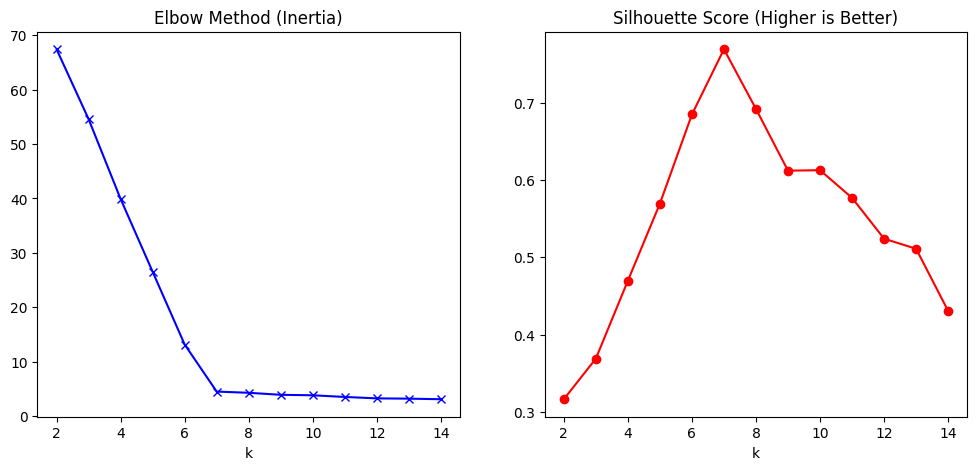

In [ ]:
inertia_list = []
silhouette_avg = []
k_range = range(2, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto" , init='k-means++')
    labels = kmeans.fit_predict(embeddings)

    inertia_list.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(embeddings, labels))

# --- Plotting the Elbow Method ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia_list, 'bx-')
plt.title('Elbow Method (Inertia)')
plt.xlabel('k')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_avg, 'ro-')
plt.title('Silhouette Score (Higher is Better)')
plt.xlabel('k')
plt.show()



In [ ]:
# Now select the best K (e.g., highest silhouette score)
k_final = k_range[silhouette_avg.index(max(silhouette_avg))]
print(f"Best K based on silhouette score: {k_final}")

Best K based on silhouette score: 7


In [ ]:
kl=KneeLocator(range(2,15),inertia_list,curve='convex',direction='decreasing')
kl.elbow

np.int64(7)

In [ ]:
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init="auto" , init='k-means++')
df["labels_final"] = kmeans_final.fit_predict(embeddings)

In [ ]:
df.sample(12)

,Teacher_ID,Full_Name,Subject,Grade_Level,Years_Exp,Regional_Priority_Skills,School_SES_Rating,Student_Teacher_Ratio,Region,Skills,Teacher_profile,labels_final
250,T1250,Teacher_250,Biology,10,13,Climate_Science,0.52,21.9,Urban,"Genetics, Microscopy, Inquiry-based Learning, ...",Teaches Biology to 10 grade. Has 13 years of e...,4
87,T1087,Teacher_87,Chemistry,9,10,Data_Ethics,0.88,19.0,Urban,"Chemical Analysis, Stoichiometry, Lab Safety, ...",Teaches Chemistry to 9 grade. Has 10 years of ...,6
39,T1039,Teacher_39,Computer Science,9,7,"AI_Literacy, Digital_Citizenship",0.76,21.0,Rural,"Python/Java, Algorithms, Web Development, Cybe...",Teaches Computer Science to 9 grade. Has 7 yea...,3
282,T1282,Teacher_282,English Literature,10,12,Standard_Curriculum,0.42,27.8,Semi-Urban,"Literary Criticism, Creative Writing, Linguist...",Teaches English Literature to 10 grade. Has 12...,2
152,T1152,Teacher_152,World History,7,14,Standard_Curriculum,0.95,13.8,Urban,"Historiography, Archival Research, Cultural Co...",Teaches World History to 7 grade. Has 14 years...,1
24,T1024,Teacher_24,Mathematics,8,11,"Data_Ethics, Mental_Health_First_Aid",0.80,17.8,Rural,"Statistical Analysis (R/SPSS), Geometry, Algeb...",Teaches Mathematics to 8 grade. Has 11 years o...,5
234,T1234,Teacher_234,Physics,10,2,Data_Ethics,0.17,31.7,Rural,"Thermodynamics, Calculus-based Modeling, Lab S...",Teaches Physics to 10 grade. Has 2 years of ex...,0
144,T1144,Teacher_144,Computer Science,10,14,"AI_Literacy, Digital_Citizenship",0.13,31.1,Urban,"Python/Java, Algorithms, Web Development, Cybe...",Teaches Computer Science to 10 grade. Has 14 y...,3
93,T1093,Teacher_93,Mathematics,8,6,"Data_Ethics, Mental_Health_First_Aid",0.82,18.8,Semi-Urban,"Statistical Analysis (R/SPSS), Geometry, Algeb...",Teaches Mathematics to 8 grade. Has 6 years of...,5
34,T1034,Teacher_34,Chemistry,9,8,Data_Ethics,0.06,34.5,Rural,"Chemical Analysis, Stoichiometry, Lab Safety, ...",Teaches Chemistry to 9 grade. Has 8 years of e...,6
